# Raw Returns Backtest — Model Comparison

## 1. Setup & Config

In [27]:
import sys
import warnings
from datetime import UTC, datetime
from pathlib import Path

import numpy as np
import pandas as pd


warnings.filterwarnings("ignore")

PROJECT_DIR = Path("/home/ra_yeye/2026_projects/nautilus_trader")
sys.path.insert(0, str(PROJECT_DIR))

from my_strategies.scripts.clickhouse_fetch_signals import fetch_signals_for_date_range
from my_strategies.scripts.clickhouse_fetch_signals_v2 import fetch_signals_v2_for_date_range
from my_strategies.utils.clickhouse_data_utils import _query_clickhouse_klines

from my_strategies.utils.plots import calculate_portfolio_performance
from my_strategies.utils.plots import plot_cum_returns
from my_strategies.utils.plots import plot_drawdown_chart
from my_strategies.utils.plots import pretty_print
from my_strategies.utils.plots import print_portfolio_performance


In [28]:
SIGNAL_START_DATE = "2024-12-01"
SIGNAL_END_DATE = datetime.now(UTC).strftime("%Y-%m-%d")

REBALANCE_HOUR = 0
SIGNAL_OFFSET_DAYS = 1

SIGNAL_FETCHERS = {
    "Jenny_v6": lambda: fetch_signals_for_date_range(
        SIGNAL_START_DATE,
        SIGNAL_END_DATE,
        save_to_file=False,
    ),
    "Maicro_v2_dow7": lambda: fetch_signals_v2_for_date_range(
        SIGNAL_START_DATE,
        SIGNAL_END_DATE,
        save_to_file=False,
    ),
}

print(f"Signal date range: {SIGNAL_START_DATE} to {SIGNAL_END_DATE}")
print(f"Models: {list(SIGNAL_FETCHERS)}")


Signal date range: 2024-12-01 to 2026-04-17
Models: ['Jenny_v6', 'Maicro_v2_dow7']


## 2. Fetch Signals & Load Prices

In [29]:
# Fetch signals from ClickHouse for each model
raw_signals = {}
for name, fetch in SIGNAL_FETCHERS.items():
    print(f"Fetching {name}...")
    raw_signals[name] = fetch()

all_symbols = set()
for df in raw_signals.values():
    all_symbols |= set(df["symbol"].unique())
print(f"Total unique symbols across models: {len(all_symbols)}")

PRICE_START_DATE = "2024-11-01"

# Load open price at rebalance hour from ClickHouse
daily_opens = {}
missing_symbols = []
for symbol in sorted(all_symbols):
    df = _query_clickhouse_klines(
        symbol=f"{symbol}USDT",
        interval="1h",
        hour_filter=REBALANCE_HOUR,
        start_date=PRICE_START_DATE,
    )
    if df.empty:
        missing_symbols.append(symbol)
        print(f"  [MISS] {symbol}USDT: no data")
        continue
    daily = df[["open"]].copy()
    daily["date"] = daily.index.date
    daily_opens[symbol] = daily.set_index("date")["open"]
    print(
        f"  [OK]   {symbol}USDT: {len(daily_opens[symbol])} bars ({daily_opens[symbol].index.min()} to {daily_opens[symbol].index.max()})"
    )

# Build price matrix and compute returns
prices_df = pd.DataFrame(daily_opens)
returns_df = prices_df.pct_change().iloc[1:]  # drop first NaN row

print(f"\nLoaded: {len(daily_opens)} / {len(all_symbols)} symbols")
if missing_symbols:
    print(f"Missing: {missing_symbols}")
print(f"Date range: {returns_df.index.min()} to {returns_df.index.max()}")
print(f"Trading days: {len(returns_df)}")
returns_df.head()

Fetching Jenny_v6...
Fetching Maicro_v2_dow7...
Total unique symbols across models: 123
  [OK]   0GUSDT: 212 bars (2025-09-18 to 2026-04-17)
  [OK]   AAVEUSDT: 533 bars (2024-11-01 to 2026-04-17)
  [OK]   ADAUSDT: 533 bars (2024-11-01 to 2026-04-17)
  [OK]   AIXBTUSDT: 483 bars (2024-12-21 to 2026-04-17)
  [OK]   ALGOUSDT: 533 bars (2024-11-01 to 2026-04-17)
  [OK]   ALTUSDT: 533 bars (2024-11-01 to 2026-04-17)
  [OK]   ANIMEUSDT: 449 bars (2025-01-24 to 2026-04-17)
  [OK]   APTUSDT: 533 bars (2024-11-01 to 2026-04-17)
  [OK]   ARUSDT: 533 bars (2024-11-01 to 2026-04-17)
  [OK]   ARBUSDT: 533 bars (2024-11-01 to 2026-04-17)
  [OK]   ASTERUSDT: 210 bars (2025-09-20 to 2026-04-17)
  [OK]   AVAXUSDT: 533 bars (2024-11-01 to 2026-04-17)
  [OK]   AVNTUSDT: 220 bars (2025-09-10 to 2026-04-17)
  [OK]   BABYUSDT: 377 bars (2025-04-06 to 2026-04-17)
  [OK]   BANANAUSDT: 533 bars (2024-11-01 to 2026-04-17)
  [OK]   BCHUSDT: 533 bars (2024-11-01 to 2026-04-17)
  [OK]   BERAUSDT: 435 bars (2025-02

,0G,AAVE,ADA,AIXBT,ALGO,ALT,ANIME,APT,AR,ARB,...,WIF,WLD,WLFI,XLM,XPL,XRP,YGG,ZEN,ZK,ZRO
date,,,,,,,,,,,,,,,,,,,,,
2024-11-02,NaN,-0.014297,0.046546,NaN,0.001748,-0.034450,NaN,-0.017597,-0.050231,-0.014044,...,-0.077682,-0.022159,NaN,0.007576,NaN,0.006869,-0.036183,-0.005835,-0.000539,-0.018976
2024-11-03,NaN,-0.021084,-0.026294,NaN,-0.006981,-0.019036,NaN,-0.033876,-0.012605,-0.029451,...,-0.008696,-0.037502,NaN,-0.004941,NaN,-0.005263,-0.052250,0.015425,-0.031664,-0.029428
2024-11-04,NaN,-0.040185,-0.041080,NaN,-0.038664,-0.048348,NaN,-0.050741,-0.037605,-0.044228,...,-0.046386,-0.045540,NaN,-0.022237,NaN,-0.014501,-0.070651,-0.031456,-0.046543,-0.022330
2024-11-05,NaN,-0.034413,-0.022768,NaN,-0.001828,-0.017478,NaN,-0.016284,-0.066037,-0.018261,...,-0.074311,-0.040880,NaN,0.005741,NaN,0.000597,-0.007478,-0.029424,-0.036382,-0.029365
2024-11-06,NaN,0.058489,0.022072,NaN,0.044872,0.060128,NaN,0.049747,0.057198,0.036356,...,0.093544,0.069065,NaN,0.025247,NaN,0.021463,0.046961,0.020020,0.041739,0.030220


## 3. Load Signals & Build Weight Matrices

In [30]:
def load_weight_matrix(raw_df: pd.DataFrame, signal_offset_days: int = 1) -> pd.DataFrame:
    df = raw_df.copy()
    df["date"] = pd.to_datetime(df["date"]).dt.date

    # Keep latest insert per (date, symbol)
    df = df.sort_values("inserted_at").drop_duplicates(subset=["date", "symbol"], keep="last")

    # Pivot to date x symbol
    weights = df.pivot(index="date", columns="symbol", values="weight").fillna(0.0)

    # Normalize: divide by gross exposure per day
    gross = weights.abs().sum(axis=1)
    weights = weights.div(gross, axis=0)

    # Align to return date: signal day S -> enter at open(S+offset) -> earn return at S+offset+1
    weights.index = pd.to_datetime(weights.index) + pd.Timedelta(days=signal_offset_days + 1)
    weights.index = weights.index.date
    weights.index.name = "date"

    return weights


# Only keep symbols that have OHLCV data
available_symbols = set(returns_df.columns)

weight_matrices = {}
for name, raw_df in raw_signals.items():
    w = load_weight_matrix(raw_df, SIGNAL_OFFSET_DAYS)
    # Check which symbols are dropped
    signal_symbols = set(w.columns)
    dropped = sorted(signal_symbols - available_symbols)
    if dropped:
        print(f"{name}: dropped {len(dropped)} symbols (no price data): {dropped}")
    # Filter to symbols with price data
    common_cols = sorted(signal_symbols & available_symbols)
    w = w[common_cols]
    weight_matrices[name] = w
    print(f"{name}: {w.shape[0]} days, {w.shape[1]} symbols")

weight_matrices["Jenny_v6"].head()

Jenny_v6: dropped 1 symbols (no price data): ['FTT']
Jenny_v6: 503 days, 121 symbols
Maicro_v2_dow7: dropped 1 symbols (no price data): ['FTT']
Maicro_v2_dow7: 454 days, 121 symbols


symbol,0G,AAVE,ADA,AIXBT,ALGO,ALT,ANIME,APT,AR,ARB,...,WIF,WLD,WLFI,XLM,XPL,XRP,YGG,ZEN,ZK,ZRO
date,,,,,,,,,,,,,,,,,,,,,
2024-12-03,0.0,0.0,-0.002036,0.0,0.000000,0.0,0.0,0.046348,0.0,0.003943,...,0.035357,-0.058241,0.0,-0.052198,0.0,-0.052392,0.0,0.0,0.0,0.0
2024-12-04,0.0,0.0,-0.045558,0.0,0.000000,0.0,0.0,0.013863,0.0,0.066367,...,-0.008985,-0.023193,0.0,-0.041411,0.0,-0.064259,0.0,0.0,0.0,0.0
2024-12-05,0.0,0.0,-0.027082,0.0,0.000000,0.0,0.0,0.053187,0.0,0.041408,...,0.032440,-0.004930,0.0,-0.042756,0.0,-0.041351,0.0,0.0,0.0,0.0
2024-12-06,0.0,0.0,0.020899,0.0,0.000000,0.0,0.0,0.049774,0.0,0.057431,...,0.057367,0.011359,0.0,-0.041798,0.0,-0.030948,0.0,0.0,0.0,0.0
2024-12-07,0.0,0.0,-0.003152,0.0,-0.019144,0.0,0.0,0.000000,0.0,0.032014,...,0.014431,-0.010711,0.0,-0.044645,0.0,-0.013953,0.0,0.0,0.0,0.0


## 4. Compute Portfolio Returns

In [31]:
portfolio_returns = {}
for name, weights in weight_matrices.items():
    # Align weights and returns on common dates and symbols
    common_dates = sorted(set(weights.index) & set(returns_df.index))
    common_syms = sorted(set(weights.columns) & set(returns_df.columns))
    w = weights.loc[common_dates, common_syms]
    r = returns_df.loc[common_dates, common_syms]
    # weight[T] * return[T]: both indexed by return date
    portfolio_returns[name] = (w * r).sum(axis=1)
    print(f"{name}: {len(common_dates)} days, {len(common_syms)} symbols")

# Merge into a single DataFrame for plotting
portfolio_df = pd.DataFrame(portfolio_returns)
portfolio_df.index.name = "date"
portfolio_df = portfolio_df.reset_index()
portfolio_df["date"] = pd.to_datetime(portfolio_df["date"])

print(
    f"\nPortfolio range: {portfolio_df['date'].min().date()} to {portfolio_df['date'].max().date()} ({len(portfolio_df)} days)"
)
portfolio_df.head()

Jenny_v6: 501 days, 121 symbols
Maicro_v2_dow7: 454 days, 121 symbols

Portfolio range: 2024-12-03 to 2026-04-17 (501 days)


,date,Jenny_v6,Maicro_v2_dow7
0,2024-12-03,-0.003269,-0.026413
1,2024-12-04,0.053489,0.061318
2,2024-12-05,0.005454,0.006782
3,2024-12-06,0.001855,-0.002550
4,2024-12-07,-0.004462,-0.008362


## 5. Compute Turnover

In [32]:
turnover = {}
for name, weights in weight_matrices.items():
    daily_to = weights.diff().abs().sum(axis=1)
    daily_to.iloc[0] = weights.iloc[0].abs().sum()  # first day: full portfolio build
    turnover[name] = daily_to

turnover_df = pd.DataFrame(turnover)
turnover_df.index.name = "date"

for name in turnover_df.columns:
    print(f"{name} — mean daily turnover: {turnover_df[name].mean():.4f}")

turnover_df.head()

Jenny_v6 — mean daily turnover: 0.9170
Maicro_v2_dow7 — mean daily turnover: 0.9090


,Jenny_v6,Maicro_v2_dow7
date,,
2024-12-03,1.000000,1.000000
2024-12-04,1.098131,0.735138
2024-12-05,0.917539,1.032266
2024-12-06,0.961732,0.894677
2024-12-07,0.880930,0.825846


## 6. Performance Summary

In [33]:
# Per-model performance
for name in SIGNAL_FETCHERS:
    print(f"\n{name}:")
    print_portfolio_performance(portfolio_df, date_col="date", ret_col=name, freq="D")


Jenny_v6:
╭────────────────┬─────────┬────────────────┬────────────────┬───────────────┬───────────────────╮
│ Total Return   │ CAGR    │   Sharpe Ratio │ Max Drawdown   │ Ann. Return   │ Ann. Volatility   │
├────────────────┼─────────┼────────────────┼────────────────┼───────────────┼───────────────────┤
│ 210.31%        │ 128.69% │           3.42 │ -10.78%        │ 85.73%        │ 25.04%            │
╰────────────────┴─────────┴────────────────┴────────────────┴───────────────┴───────────────────╯

Maicro_v2_dow7:
╭────────────────┬─────────┬────────────────┬────────────────┬───────────────┬───────────────────╮
│ Total Return   │ CAGR    │   Sharpe Ratio │ Max Drawdown   │ Ann. Return   │ Ann. Volatility   │
├────────────────┼─────────┼────────────────┼────────────────┼───────────────┼───────────────────┤
│ 141.59%        │ 103.65% │            2.7 │ -12.18%        │ 74.80%        │ 27.68%            │
╰────────────────┴─────────┴────────────────┴────────────────┴───────────────┴───

## 7. Plots

### Cumulative Returns

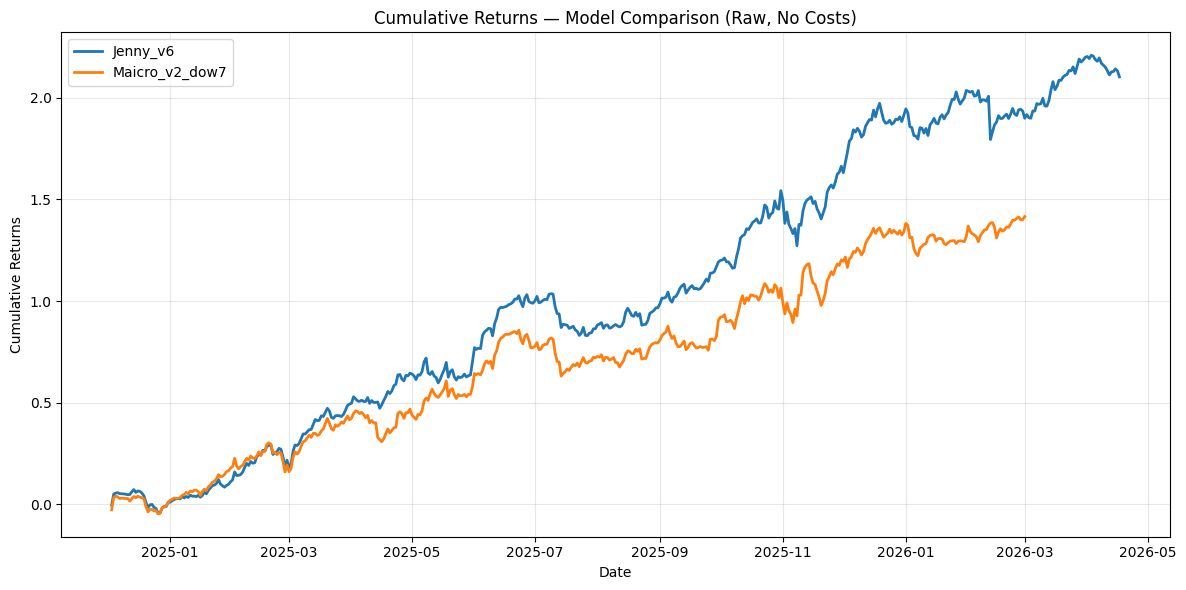

In [34]:
model_names = list(SIGNAL_FETCHERS.keys())
plot_cum_returns(
    portfolio_df,
    index_col_name="date",
    ret_col_lst=model_names,
    title="Cumulative Returns — Model Comparison (Raw, No Costs)",
)

### Drawdown


Jenny_v6:


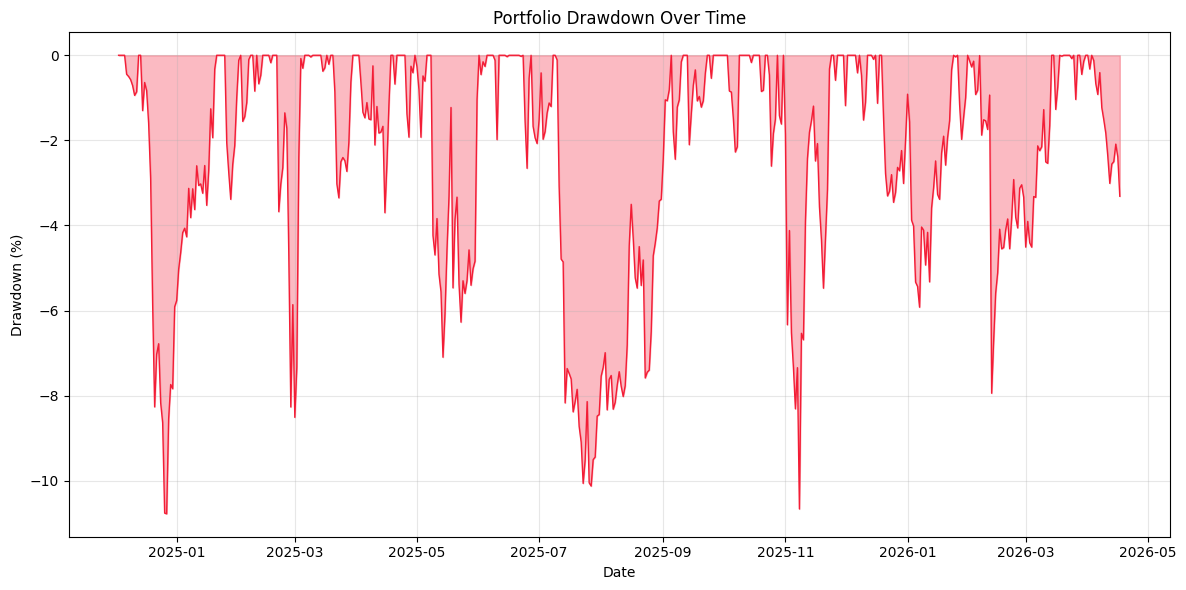


Maicro_v2_dow7:


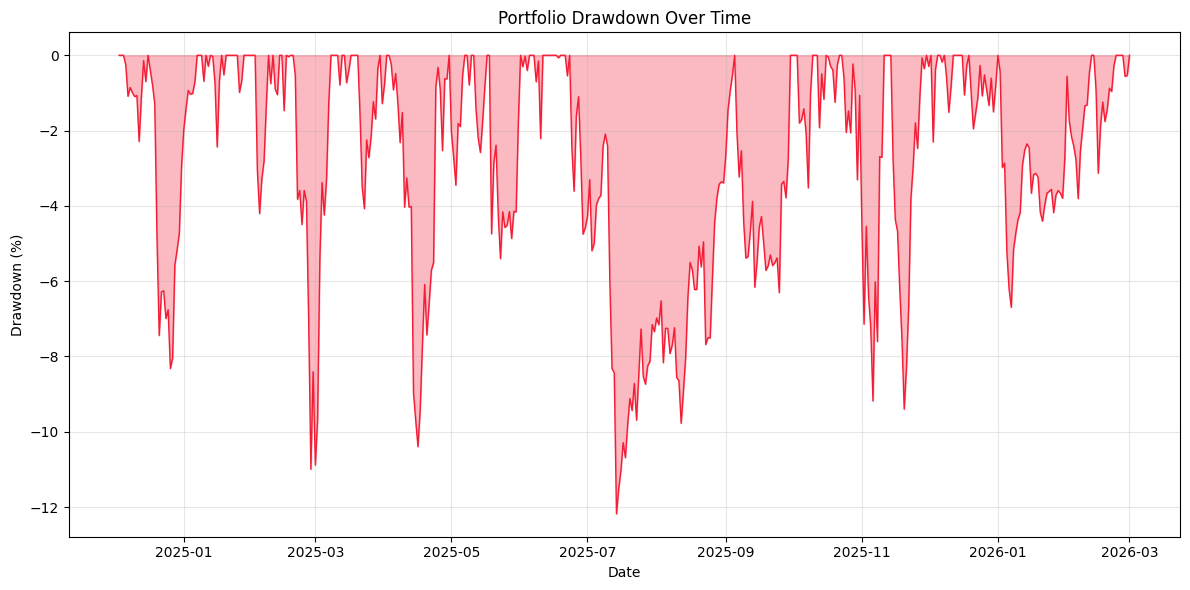

In [35]:
for name in model_names:
    print(f"\n{name}:")
    plot_drawdown_chart(portfolio_df, date_col="date", ret_col=name)

### Cumulative Turnover

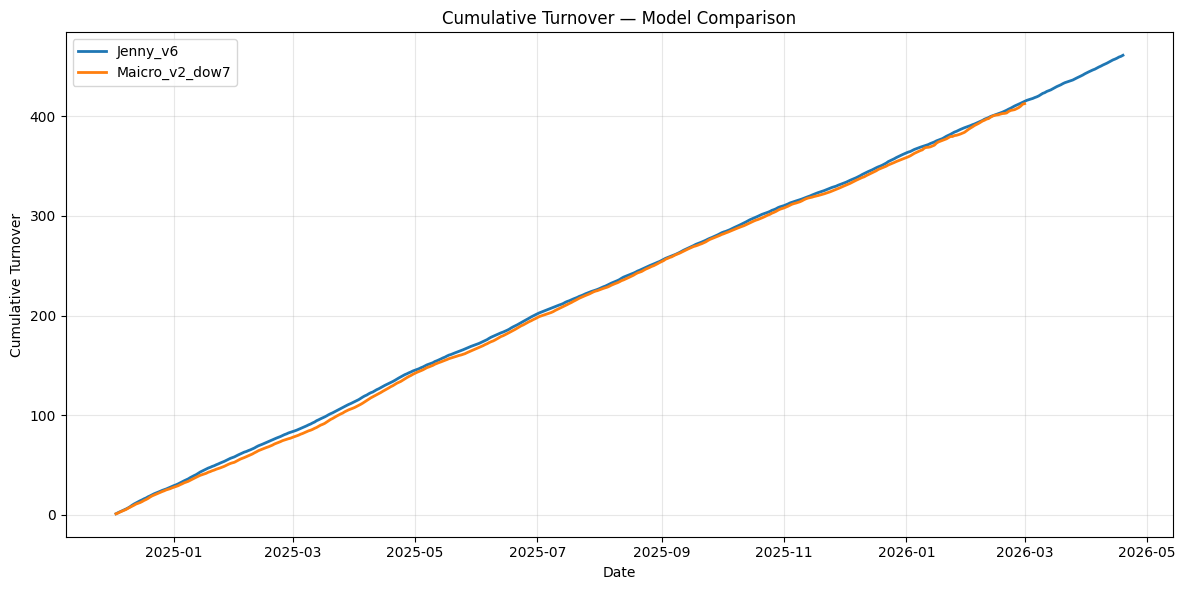

In [36]:
import matplotlib.pyplot as plt
from my_strategies.utils.plots import DEFAULT_FIGSIZE

plt.figure(figsize=DEFAULT_FIGSIZE)
for name in model_names:
    cum_to = turnover_df[name].cumsum()
    plt.plot(turnover_df.index, cum_to, label=name, linewidth=2)

plt.xlabel("Date")
plt.ylabel("Cumulative Turnover")
plt.title("Cumulative Turnover — Model Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Cost-Adjusted Returns

In [37]:
TAKER_FEE_BPS = 4.5
SLIPPAGE_BPS = 5.0
TOTAL_COST_BPS = TAKER_FEE_BPS + SLIPPAGE_BPS

# Align turnover_df dates with portfolio_df dates
turnover_aligned = turnover_df.loc[portfolio_df["date"].dt.date.values]

# net_return = gross_return - turnover * cost
portfolio_net_df = portfolio_df.copy()
for name in model_names:
    portfolio_net_df[name] = (
        portfolio_df[name].values - turnover_aligned[name].values * TOTAL_COST_BPS / 10_000
    )

print(f"Total cost: {TOTAL_COST_BPS} bps (taker fee: {TAKER_FEE_BPS} + slippage: {SLIPPAGE_BPS})")
portfolio_net_df.head()

Total cost: 9.5 bps (taker fee: 4.5 + slippage: 5.0)


,date,Jenny_v6,Maicro_v2_dow7
0,2024-12-03,-0.004219,-0.027363
1,2024-12-04,0.052446,0.060620
2,2024-12-05,0.004582,0.005801
3,2024-12-06,0.000942,-0.003400
4,2024-12-07,-0.005299,-0.009146


In [38]:
# Side-by-side: gross vs net
rows = []
for name in model_names:
    g = calculate_portfolio_performance(portfolio_df, "date", name, "D")
    n = calculate_portfolio_performance(portfolio_net_df, "date", name, "D")
    rows.append(
        {
            "Model": name,
            "Gross Return": f"{g['total_return'] * 100:.2f}%",
            "Net Return": f"{n['total_return'] * 100:.2f}%",
            "Gross Sharpe": f"{g['sharpe_ratio']:.2f}",
            "Net Sharpe": f"{n['sharpe_ratio']:.2f}",
            "Max DD (Net)": f"{n['max_drawdown'] * 100:.2f}%",
            "Mean Daily TO": f"{turnover_df[name].mean():.4f}",
        }
    )

pretty_print(pd.DataFrame(rows))

╭────────────────┬────────────────┬──────────────┬────────────────┬──────────────┬────────────────┬─────────────────╮
│ Model          │ Gross Return   │ Net Return   │   Gross Sharpe │   Net Sharpe │ Max DD (Net)   │   Mean Daily TO │
├────────────────┼────────────────┼──────────────┼────────────────┼──────────────┼────────────────┼─────────────────┤
│ Jenny_v6       │ 210.31%        │ 100.71%      │           3.42 │         2.15 │ -12.27%        │           0.917 │
├────────────────┼────────────────┼──────────────┼────────────────┼──────────────┼────────────────┼─────────────────┤
│ Maicro_v2_dow7 │ 141.59%        │ 63.32%       │           2.7  │         1.56 │ -13.79%        │           0.909 │
╰────────────────┴────────────────┴──────────────┴────────────────┴──────────────┴────────────────┴─────────────────╯


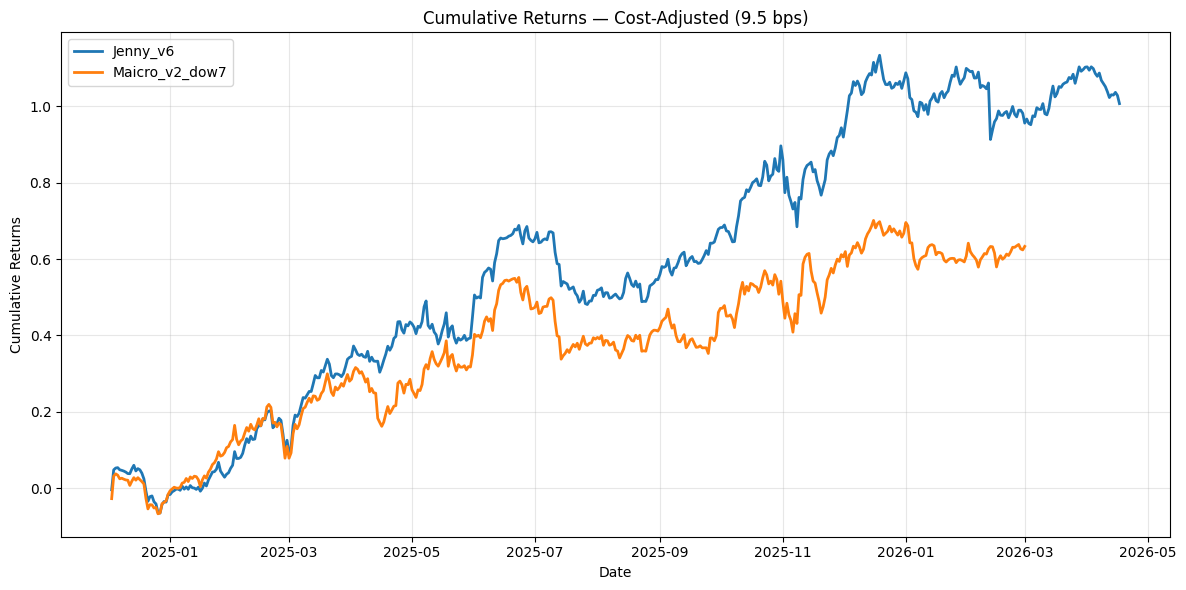

In [39]:
plot_cum_returns(
    portfolio_net_df,
    index_col_name="date",
    ret_col_lst=model_names,
    title=f"Cumulative Returns — Cost-Adjusted ({TOTAL_COST_BPS:.1f} bps)",
)

## 9. Jenny_v6 vs BTC Return Correlation

In [40]:
jenny = portfolio_df.set_index("date")["Jenny_v6"]
jenny.index = jenny.index.date
btc = returns_df["BTC"]

aligned = pd.concat({"Jenny_v6": jenny, "BTC": btc}, axis=1).dropna()
pearson = aligned["Jenny_v6"].corr(aligned["BTC"])
beta, intercept = np.polyfit(aligned["BTC"], aligned["Jenny_v6"], 1)

print(f"Aligned days:       {len(aligned)}")
print(f"Pearson correlation: {pearson:.4f}")
print(f"Beta (Jenny on BTC): {beta:.4f}")

Aligned days:       501
Pearson correlation: -0.1206
Beta (Jenny on BTC): -0.0666


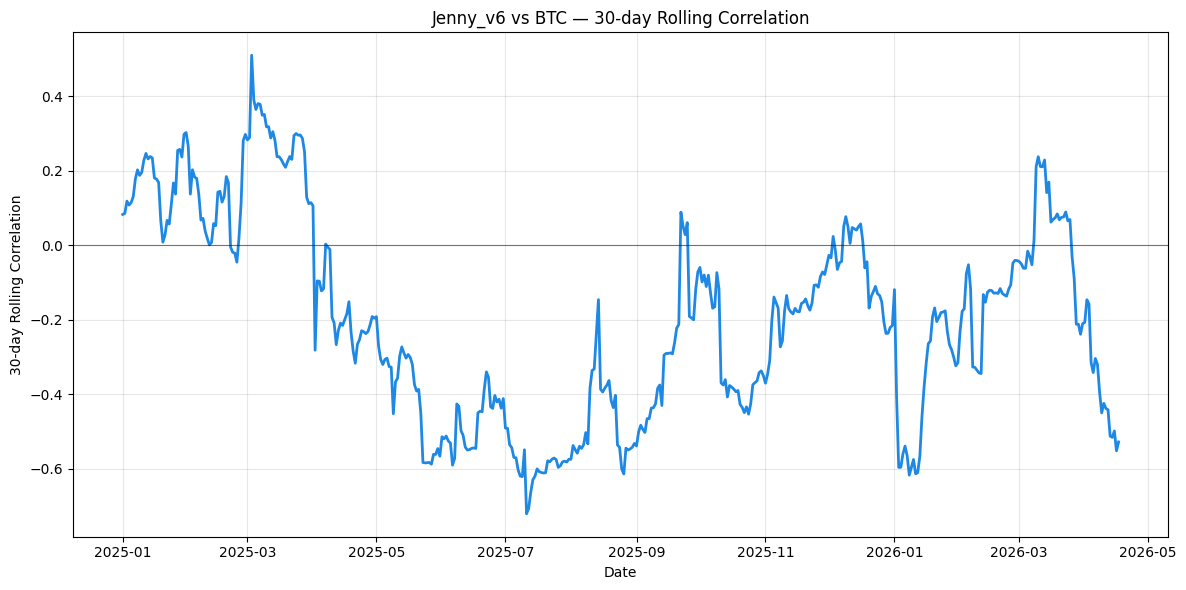

In [41]:
from my_strategies.utils.plots import BLUE_HEX, DEFAULT_FIGSIZE

ROLL_WINDOW = 30
rolling_corr = aligned["Jenny_v6"].rolling(ROLL_WINDOW).corr(aligned["BTC"])

plt.figure(figsize=DEFAULT_FIGSIZE)
plt.plot(rolling_corr.index, rolling_corr.values, color=BLUE_HEX, linewidth=2)
plt.axhline(0, color="black", linewidth=0.8, alpha=0.5)
plt.xlabel("Date")
plt.ylabel(f"{ROLL_WINDOW}-day Rolling Correlation")
plt.title(f"Jenny_v6 vs BTC — {ROLL_WINDOW}-day Rolling Correlation")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

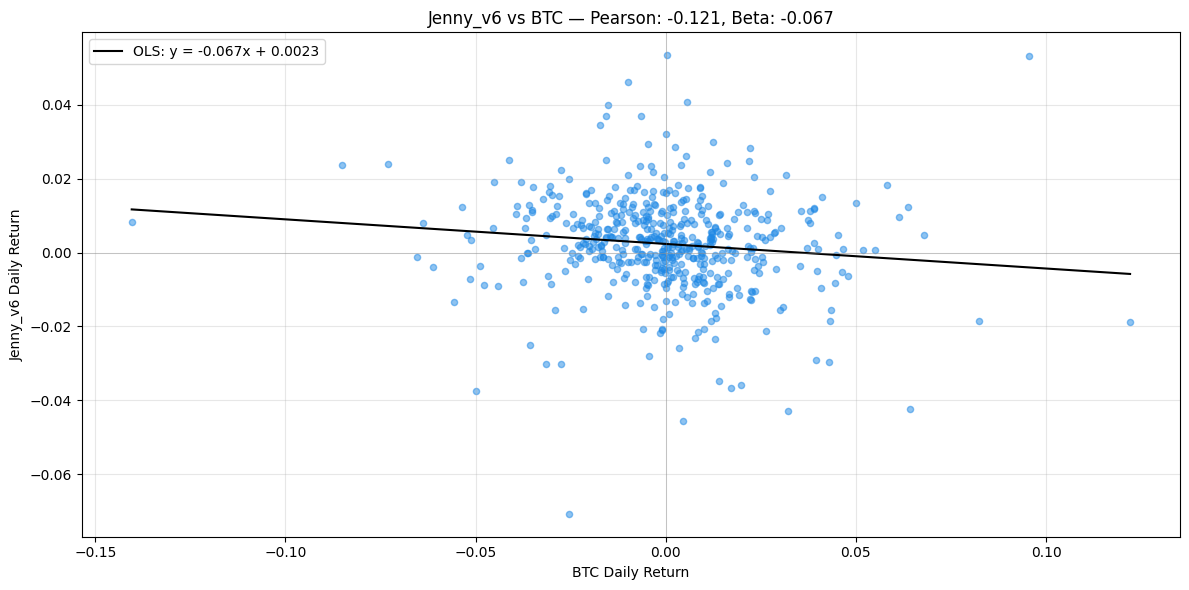

In [42]:
x = aligned["BTC"].values
y = aligned["Jenny_v6"].values
line_x = np.array([x.min(), x.max()])
line_y = beta * line_x + intercept

plt.figure(figsize=DEFAULT_FIGSIZE)
plt.scatter(x, y, alpha=0.5, color=BLUE_HEX, s=20)
plt.plot(
    line_x, line_y, color="black", linewidth=1.5, label=f"OLS: y = {beta:.3f}x + {intercept:.4f}"
)
plt.axhline(0, color="gray", linewidth=0.5, alpha=0.5)
plt.axvline(0, color="gray", linewidth=0.5, alpha=0.5)
plt.xlabel("BTC Daily Return")
plt.ylabel("Jenny_v6 Daily Return")
plt.title(f"Jenny_v6 vs BTC — Pearson: {pearson:.3f}, Beta: {beta:.3f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()